# 1 · Standard SuSiE (univariate Gaussian)

The classic [SuSiE](https://doi.org/10.1111/rssb.12388) fine-mapping setup: one
continuous phenotype, a region of correlated variants (LD), and a handful of true
causal signals hiding in the correlation. We want, for each variant, a **posterior
inclusion probability (PIP)**, and a small **credible set** per signal that is very
likely to contain the true causal variant.

In `lasusie` every model is built from four orthogonal axes:

| axis | this notebook |
|------|---------------|
| **design**     | `SharedDesign(X)` — one genotype matrix, `eta = X @ B` |
| **likelihood** | `gaussian(y, sigma2=...)` — identity link, EB residual variance |
| **prior**      | `susie(sigma0_sq=...)` — single Gaussian `N(0, sigma0^2)` |
| **inclusion**  | `log_pi` — uniform over variants |

`finemap` then runs the (variance-propagating) IBSS loop and returns PIPs + credible sets.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context="notebook", style="whitegrid")
rng = np.random.default_rng(0)  # NumPy RNG for the simulations (deterministic)

In [2]:
def plot_pips(pip, causal, title, ax=None):
    """Stem plot of per-variant PIPs, with the true causal variants highlighted."""
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 3))
    m = np.arange(len(pip))
    ax.vlines(m, 0, pip, color="0.75", lw=1)
    ax.scatter(m, pip, s=12, color="0.4", label="variants")
    ax.scatter(causal, np.asarray(pip)[list(causal)], s=70, color="crimson",
               zorder=3, label="true causal")
    ax.set(xlabel="variant index", ylabel="PIP", ylim=(-0.02, 1.05), title=title)
    ax.legend(loc="upper right", frameon=True)
    return ax


def credible_set_table(result):
    """Tidy DataFrame summarising the credible sets that passed the purity filter."""
    rows = []
    for cs in result.credible_sets:
        if not cs.kept:
            continue
        rows.append({
            "effect": cs.effect,
            "size": len(cs.variants),
            "coverage": round(float(cs.coverage), 3),
            "purity": round(float(cs.purity), 3),
            "variants": list(np.asarray(cs.variants)[:8]),
        })
    return pd.DataFrame(rows)


## Simulate a region with LD

We give the variants realistic linkage disequilibrium by sampling genotypes with an
AR(1) correlation `rho^|i-j|`, then standardise each column (SuSiE expects
mean-0 / unit-variance predictors). Two variants are truly causal.

In [3]:
N, M = 800, 150            # individuals, variants
rho = 0.9                  # AR(1) LD strength between neighbouring variants

idx = np.arange(M)
Sigma_ld = rho ** np.abs(idx[:, None] - idx[None, :])
chol = np.linalg.cholesky(Sigma_ld + 1e-6 * np.eye(M))
X = rng.standard_normal((N, M)) @ chol.T
X = (X - X.mean(0)) / X.std(0)

causal = [30, 100]         # true causal variant indices
betas = np.array([0.7, -0.5])
y = X[:, causal] @ betas + rng.standard_normal(N) * 1.0
print("X:", X.shape, " y:", y.shape, " causal:", causal)

X: (800, 150)  y: (800,)  causal: [30, 100]


## Build the model and fine-map

`L` is the number of single effects (an upper bound on the number of signals). We ask
for 95% credible sets and drop any set whose purity (minimum absolute pairwise
correlation) falls below 0.5.

In [4]:
from lasusie import finemap, Model, likelihoods, priors
from lasusie.design import SharedDesign

model = Model(
    design=SharedDesign(X=jnp.asarray(X)),
    likelihood=likelihoods.gaussian(jnp.asarray(y).reshape(-1, 1), sigma2=1.0),
    prior=priors.susie(sigma0_sq=1.0),
    log_pi=jnp.full(M, -jnp.log(M)),
)

result = finemap(model, L=5, coverage=0.95, purity=0.5)
print(f"converged={result.converged}  iterations={result.iterations}  ELBO={result.elbo:.1f}")

converged=True  iterations=67  ELBO=-1153.4


## Results: PIPs and credible sets

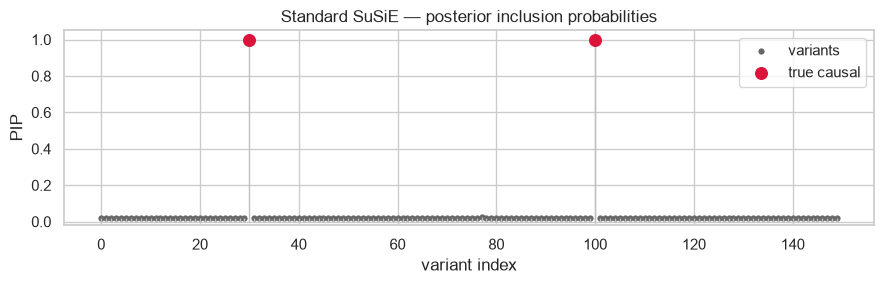

,effect,size,coverage,purity,variants
0,0,1,1.0,1.0,[30]
1,1,1,1.0,1.0,[100]


In [5]:
plot_pips(result.pip, causal, "Standard SuSiE — posterior inclusion probabilities")
plt.tight_layout(); plt.show()

credible_set_table(result)

Each kept credible set should be a small cluster of variants in tight LD, and it should
contain one of the true causal variants (marked in red above). Because the two causal
variants sit in correlated neighbourhoods, the PIP mass for each signal is spread across
its LD block — exactly what a credible set is designed to capture.

### Where the numbers live

- `result.pip` — `(M,)` per-variant PIP
- `result.alpha` — `(L, M)` inclusion probabilities per single effect
- `result.credible_sets` — list of `CredibleSet(effect, variants, coverage, purity, kept)`
- `result.posterior.mean` — `(L, M, K)` posterior effect-size means (`K=1` here)
- `result.elbo_history` — ELBO per sweep (a convergence diagnostic)

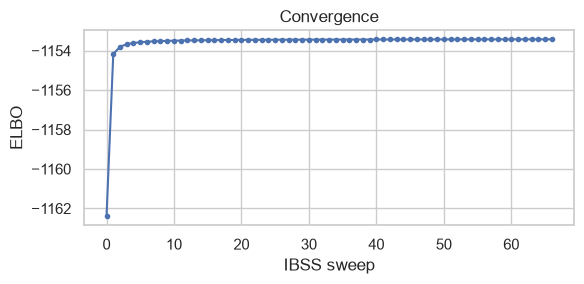

In [6]:
plt.figure(figsize=(6, 3))
plt.plot(result.elbo_history, marker="o", ms=3)
plt.xlabel("IBSS sweep"); plt.ylabel("ELBO"); plt.title("Convergence")
plt.tight_layout(); plt.show()